In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.calibrator.pca_factor_extractor import PCAFactorExtractor
from src.curves.calibrator.ou_factor_calibrator import OUFactorCalibrator

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..


In [3]:
# yield curve history
curve_history = market_curves['treasury']
curve_history

,1M,3M,6M,1Y,2Y,5Y,10Y,30Y
Date,,,,,,,,
2019-10-01,1.79,1.82,1.81,1.73,1.56,1.51,1.65,2.11
2019-10-02,1.75,1.79,1.75,1.67,1.48,1.43,1.60,2.09
2019-10-03,1.78,1.70,1.66,1.58,1.39,1.34,1.54,2.04
2019-10-04,1.73,1.71,1.65,1.58,1.40,1.34,1.52,2.01
2019-10-07,1.76,1.75,1.73,1.64,1.46,1.38,1.56,2.05
...,...,...,...,...,...,...,...,...
2026-06-04,3.71,3.78,3.78,3.82,4.05,4.18,4.47,4.97
2026-06-05,3.71,3.78,3.81,3.88,4.17,4.29,4.55,5.01
2026-06-08,3.70,3.80,3.83,3.85,4.15,4.29,4.56,5.03


In [4]:
### PCA factor extractor
# initialize PCA factor extractor
pca = PCAFactorExtractor(n_factors = 2)

# fitting PCAs to historical yield changes and projecting onto factors
factor_history = pca.fit_transform(yield_curve_history = curve_history)

# explained variance of PCA factors
variance_report = pca.variance_report()
variance_report

,Component,ExplainedVariance,CumulativeVariance
0,PC1,0.648120,0.648120
1,PC2,0.145519,0.793639
2,PC3,0.116726,0.910365
3,PC4,0.051388,0.961753
4,PC5,0.018744,0.980497
5,PC6,0.009297,0.989794
6,PC7,0.007823,0.997616
7,PC8,0.002384,1.000000


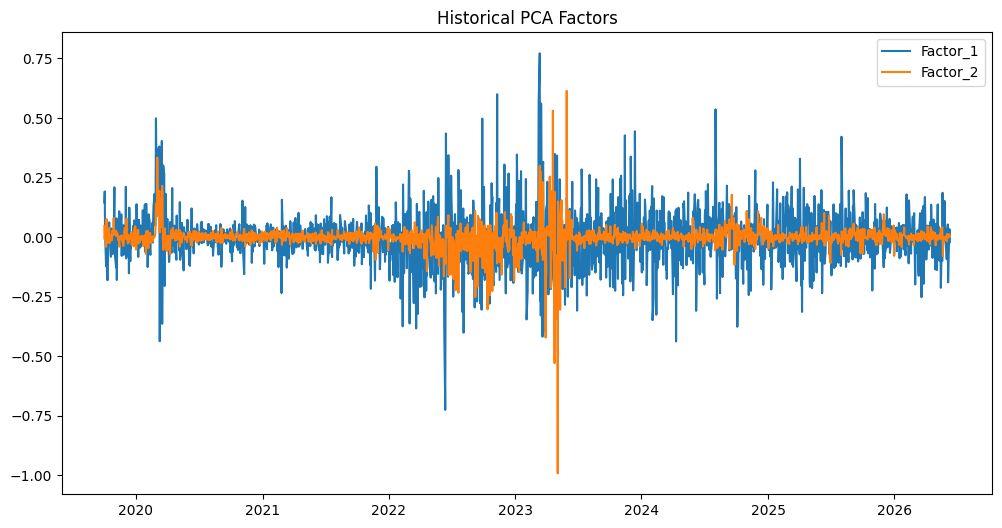

In [5]:
# plot PCA factors
plt.figure(figsize = (12, 6))

plt.plot(factor_history.index, factor_history['Factor_1'], label = 'Factor_1')
plt.plot(factor_history.index, factor_history['Factor_2'], label = 'Factor_2')
plt.title('Historical PCA Factors')
plt.legend(loc = 'best')
plt.show()

In [6]:
# factor loadings
factor_loadings = pca.get_factor_loadings()
factor_loadings.index = curve_history.columns
factor_loadings 

,Factor1,Factor2
1M,-0.040649,-0.955008
3M,-0.117023,-0.158067
6M,-0.193153,-0.125755
1Y,-0.329788,-0.108476
2Y,-0.470490,-0.033994
5Y,-0.509812,0.062522
10Y,-0.463166,0.107123
30Y,-0.377880,0.137305


In [7]:
# Ornstein-Uhlenbeck factor calibration
ou_calibrator = OUFactorCalibrator(dt = 1/252)

# calibrate HW 2-factor model parameters
hw2f_params = ou_calibrator.calibrate_hw2f(factor_history = factor_history)
hw2f_params

{'a': 1123.4513713602098,
 'b': 641.4442266132614,
 'sigma1': 5.590537118271106,
 'sigma2': 2.0021781774553182,
 'rho': -0.017142984702361003}